In [1]:
!pip install "numpy<2"
import os
import pandas as pd

In [2]:
#chunk_size = 100000  # Adjust chunk size as needed
#chunks = pd.read_csv("Twitter-historical-20060321-20090731.txt", delimiter="\t", chunksize=chunk_size)

#chunks


- https://seositecheckup.com/seo-audit/www.forum4farming.com
- https://technicalseo.com/tools/robots-txt/
  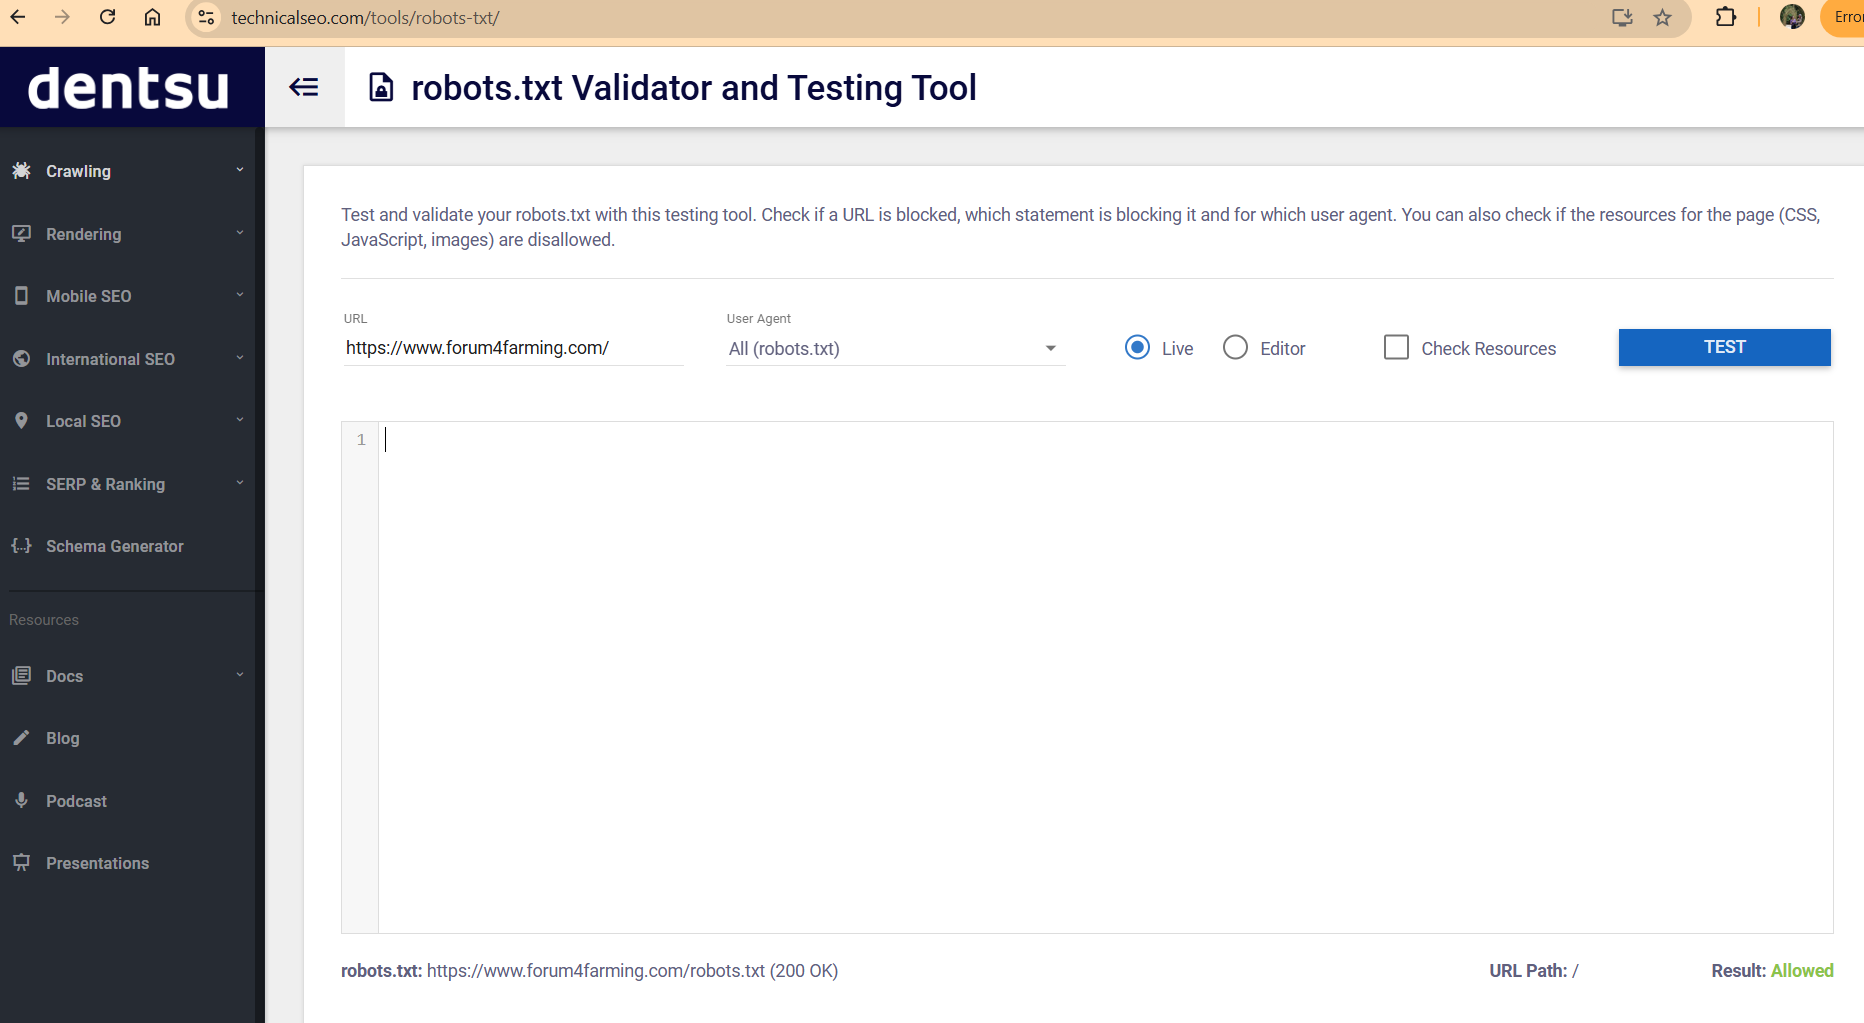
  

In [4]:
#tweets

In [5]:
#!pip install requests beautifulsoup4

In [6]:
from bs4 import BeautifulSoup
import requests
import csv
import re

In [7]:
# Base URL for the thread
base_url = "https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-"

#opening a csv file for comments to be saved into
with open('thread.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Thread Content'])  # Header row
    
#want to repeat for https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-2... up to page-24
# Loop over pages 1 to 24
    for page_num in range(1, 25):
        url = f"{base_url}{page_num}"
        print(f"Scraping page {page_num}: {url}")

# Using a GET request to fetch the raw HTML content
        html_content = requests.get(url).text

# Parsing the html content
        soup = BeautifulSoup(html_content, "lxml")

# trying to extract all the forum posts
        posts = soup.find_all('div', itemprop='text')  

        for post in posts:
        # get content from inside the bbWrapper div
            post_div = post.find('div', class_='bbWrapper')
        
        # Extracting text and dealing with <br/>, removing unnecessary spaces
            if post_div:
                post_text = post_div.get_text(separator=' ', strip=True)
# Remove all text up to and including "Click to expand..." so only have comment content and not repeats of posts they reply to
                cleaned_post_text = re.sub(r"^.*?Click to expand\.\.\..", "", post_text, flags=re.DOTALL)
#add extracted text to the opened csv file
                writer.writerow([cleaned_post_text])
print("Posts have been saved sucessfully to 'thread.csv'.")
#print(soup.prettify()) # print the parsed data of html removed after found where comments were stored

Scraping page 1: https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-1
Scraping page 2: https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-2
Scraping page 3: https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-3
Scraping page 4: https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-4
Scraping page 5: https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-5
Scraping page 6: https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-6
Scraping page 7: https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-7
Scraping page 8: https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-8
Scraping page 9: https://www.forum4farming.com/forum/index.php?threads/winter-wheat-2024.22804/page-9
Scraping page 10: https://www.forum4farming.com/forum/index.php?threads/winter-whe

In [8]:
#get title of webpage
print(soup.title.text)

Winter Wheat 2024 | Page 24 | Forum4Farming - Britain & Ireland Farming Forum, Agricultural Discussion Boards. IE & UK


The thread posts are all in response to this article: https://goldcrop.ie/kws-dawsum-everything-i-want-in-a-wheat-variety/

after using prettify could identify what part of html heald the thread comments

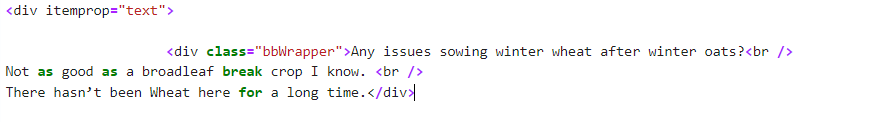

In [11]:
# read in csv file
forum_posts = pd.read_csv('thread.csv')
forum_posts.head()

,Thread Content
0,Any issues sowing winter wheat after winter oa...
1,"No issues at all, they can be a good break crop."
2,"I find it a good bit hungrier, and slower to d..."
3,I think the alleopathy effect of the oats can ...
4,"I wouldn't disagree on the winter barley, but ..."


want to remove usernames and repeats of comments from comments that are a reply to other users posts
usernames are only appearing when comments are being reposted after replies
added line to code to appply this filter before adding to csv file


https://docs.python.org/3/library/re.html .... library for changing strings

## Feature Extraction for sentiment analysis

In [15]:
import nltk
!pip install -U textblob 
from nltk.stem import PorterStemmer 
from textblob import TextBlob 
from textblob import Word 
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.feature_extraction.text import CountVectorizer 


In [16]:
#working out the number of words. Often moore negative comments have less words
forum_posts['word_count'] = forum_posts['Thread Content'].apply(lambda x: len(str(x).split(" "))) 
forum_posts[['Thread Content','word_count']].head() 

,Thread Content,word_count
0,Any issues sowing winter wheat after winter oa...,27
1,"No issues at all, they can be a good break crop.",11
2,"I find it a good bit hungrier, and slower to d...",51
3,I think the alleopathy effect of the oats can ...,40
4,"I wouldn't disagree on the winter barley, but ...",34


In [17]:
# get number of characters
forum_posts['char_count'] = forum_posts['Thread Content'].str.len() 
## this also includes spaces 
forum_posts[['Thread Content','char_count']].head() 


,Thread Content,char_count
0,Any issues sowing winter wheat after winter oa...,141.0
1,"No issues at all, they can be a good break crop.",48.0
2,"I find it a good bit hungrier, and slower to d...",252.0
3,I think the alleopathy effect of the oats can ...,213.0
4,"I wouldn't disagree on the winter barley, but ...",182.0


In [18]:
forum_posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Thread Content  594 non-null    object 
 1   word_count      599 non-null    int64  
 2   char_count      594 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 14.2+ KB


In [19]:
forum_posts.shape

(599, 3)

In [20]:
#there are some null values in Thread Content. Removing these rows before continuing. There is enough data without these 5 instances
forum_posts = forum_posts.dropna()

In [21]:
#calculating average word length
def avg_word(sentence): 
 words = sentence.split() 
 return (sum(len(word) for word in words)/len(words)) 
forum_posts['avg_word'] = forum_posts['Thread Content'].apply(lambda x: avg_word(x)) 
forum_posts[['Thread Content','avg_word']].head() 

,Thread Content,avg_word
0,Any issues sowing winter wheat after winter oa...,4.259259
1,"No issues at all, they can be a good break crop.",3.454545
2,"I find it a good bit hungrier, and slower to d...",3.960784
3,I think the alleopathy effect of the oats can ...,4.350000
4,"I wouldn't disagree on the winter barley, but ...",4.382353


In [22]:
#getting number of stopwords
nltk.download('stopwords') 
from nltk.corpus import stopwords 
stop = stopwords.words('english') 
forum_posts['stopwords'] = forum_posts['Thread Content'].apply(lambda x: len([x for x in 
x.split() if x in stop])) 
forum_posts[['Thread Content','stopwords']].head() 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OKavanagh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Thread Content,stopwords
0,Any issues sowing winter wheat after winter oa...,8
1,"No issues at all, they can be a good break crop.",5
2,"I find it a good bit hungrier, and slower to d...",21
3,I think the alleopathy effect of the oats can ...,15
4,"I wouldn't disagree on the winter barley, but ...",16


In [23]:
#number of special characters
forum_posts['ats'] = forum_posts['Thread Content'].apply(lambda x: len([x for x in x.split() 
if x.startswith('@')])) 
forum_posts[['Thread Content','ats']].head() 

,Thread Content,ats
0,Any issues sowing winter wheat after winter oa...,0
1,"No issues at all, they can be a good break crop.",0
2,"I find it a good bit hungrier, and slower to d...",0
3,I think the alleopathy effect of the oats can ...,0
4,"I wouldn't disagree on the winter barley, but ...",0


In [24]:
forum_posts["ats"].value_counts()

ats
0    569
1     24
2      1
Name: count, dtype: int64

these @ values possibly containg usernames for other users who have commented in the thread

In [26]:
#number of numerics
forum_posts['numerics'] = forum_posts['Thread Content'].apply(lambda x: len([x for x in 
x.split() if x.isdigit()])) 
forum_posts[['Thread Content','numerics']].head() 

,Thread Content,numerics
0,Any issues sowing winter wheat after winter oa...,0
1,"No issues at all, they can be a good break crop.",0
2,"I find it a good bit hungrier, and slower to d...",0
3,I think the alleopathy effect of the oats can ...,0
4,"I wouldn't disagree on the winter barley, but ...",0


In [27]:
forum_posts["numerics"].value_counts()

numerics
0    479
1     76
2     23
3      8
4      4
7      2
6      1
5      1
Name: count, dtype: int64

In [28]:
#number of Uppercase words
forum_posts['upper'] = forum_posts['Thread Content'].apply(lambda x: len([x for x in x.split() 
if x.isupper()])) 
forum_posts[['Thread Content','upper']].head() 

,Thread Content,upper
0,Any issues sowing winter wheat after winter oa...,1
1,"No issues at all, they can be a good break crop.",0
2,"I find it a good bit hungrier, and slower to d...",2
3,I think the alleopathy effect of the oats can ...,2
4,"I wouldn't disagree on the winter barley, but ...",2


# Pre-processing

In [30]:
# get all text to lowercase
forum_posts['Thread Content'] = forum_posts['Thread Content'].apply(lambda x: " ".join(x.lower() for x in 
x.split())) 
forum_posts['Thread Content'].head() 

0    any issues sowing winter wheat after winter oa...
1     no issues at all, they can be a good break crop.
2    i find it a good bit hungrier, and slower to d...
3    i think the alleopathy effect of the oats can ...
4    i wouldn't disagree on the winter barley, but ...
Name: Thread Content, dtype: object

In [31]:
# remove punctuation
forum_posts['Thread Content'] = forum_posts['Thread Content'].str.replace(r'[^\w\s]','', regex=True) 
forum_posts['Thread Content'].head()

#regex=True to get pandas to treat the comments as regular expressions

0    any issues sowing winter wheat after winter oa...
1       no issues at all they can be a good break crop
2    i find it a good bit hungrier and slower to de...
3    i think the alleopathy effect of the oats can ...
4    i wouldnt disagree on the winter barley but i ...
Name: Thread Content, dtype: object

In [32]:
# removing stop words
from nltk.corpus import stopwords 
stop = stopwords.words('english') 
forum_posts['Thread Content'] = forum_posts['Thread Content'].apply(lambda x: " ".join(x for x in 
x.split() if x not in stop)) 
forum_posts['Thread Content'].head() 

0    issues sowing winter wheat winter oats good br...
1                               issues good break crop
2    find good bit hungrier slower develop like put...
3    think alleopathy effect oats slow wheat initia...
4    wouldnt disagree winter barley think partly fe...
Name: Thread Content, dtype: object

Removal of common words. Check first to see what most common words in thread are and them amke call to keep or remove.

In [34]:
#checking 10 most frequent words
freq = pd.Series(' '.join(forum_posts['Thread Content']).split()).value_counts()[:15] 
freq 


wheat     205
winter     95
year       89
would      89
barley     70
dawsum     70
last       68
good       64
think      64
bit        61
sown       61
field      59
crop       56
get        53
going      53
Name: count, dtype: int64

In [35]:
#want to keep "good" as this would be an important word in sentiment analysis. The rest may cause noise
#good to see that "wheat" is occuring most, forum meets the requirements of this data
freq = freq.drop('good')
freq

wheat     205
winter     95
year       89
would      89
barley     70
dawsum     70
last       68
think      64
bit        61
sown       61
field      59
crop       56
get        53
going      53
Name: count, dtype: int64

In [36]:
# removing the agricultural and farming related words from this list as thse are important for the context of the sentiment analysis
freq.drop(["wheat", "winter", "barley", "dawsum", "sown", "field", "crop"])

year     89
would    89
last     68
think    64
bit      61
get      53
going    53
Name: count, dtype: int64

In [37]:
# removing unnecessary frequent words
freq = list(freq.index) 
forum_posts['Thread Content'] = forum_posts['Thread Content'].apply(lambda x: " ".join(x for x in 
x.split() if x not in freq)) 
forum_posts['Thread Content'].head() 


0    issues sowing oats good broadleaf break know h...
1                                    issues good break
2    find good hungrier slower develop like put slu...
3    alleopathy effect oats slow initially gets nea...
4    wouldnt disagree partly fert tends put earlier...
Name: Thread Content, dtype: object

In [38]:
# checking 15 most rare words
infreq = pd.Series(' '.join(forum_posts['Thread Content']).split()).value_counts()[-15:] 
infreq 

damaged        1
appreciated    1
disturbance    1
causing        1
holiday        1
somebody       1
discover       1
keeping        1
juanuary       1
digit          1
double         1
lawn           1
thermometer    1
simple         1
optimistic     1
Name: count, dtype: int64

In [ ]:
#fix spelling before dropping infrequent words to deal with "juanuary"
#this step takes a great deal of time, after seeing accuracy of models I am not convinced it is worth the time expense
forum_posts['Thread Content'].apply(lambda x: str(TextBlob(x).correct())) 


In [40]:
# checking 15 most rare words
infreq = pd.Series(' '.join(forum_posts['Thread Content']).split()).value_counts()[-15:] 
infreq 

damaged        1
appreciated    1
disturbance    1
causing        1
holiday        1
somebody       1
discover       1
keeping        1
juanuary       1
digit          1
double         1
lawn           1
thermometer    1
simple         1
optimistic     1
Name: count, dtype: int64

In [41]:
# Manually fix january spelling error
forum_posts['Thread Content'] = forum_posts['Thread Content'].str.replace("juanuary", "january")
# checking 15 most rare words
infreq = pd.Series(' '.join(forum_posts['Thread Content']).split()).value_counts()[-15:] 
infreq

weigh          1
fabulous       1
qualities      1
costing        1
fact           1
marketing      1
seminar        1
dept           1
weakness       1
locally        1
marketsell     1
pet            1
fooling        1
progressing    1
optimistic     1
Name: count, dtype: int64

In [42]:
#keeping "optimistic", "fabulous", "weakness" and "progressing", "qualities" as I think these will be important for sentiment analysis. 
#Do not feel the other words will be that important to the overall sentiment/ context.
infreq.drop(["optimistic", "fabulous", "weakness", "progressing", "qualities"])

# removing unnecessary infrequent words
infreq = list(infreq.index) 
forum_posts['Thread Content'] = forum_posts['Thread Content'].apply(lambda x: " ".join(x for x in 
x.split() if x not in infreq)) 
forum_posts['Thread Content'].head() 

0    issues sowing oats good broadleaf break know h...
1                                    issues good break
2    find good hungrier slower develop like put slu...
3    alleopathy effect oats slow initially gets nea...
4    wouldnt disagree partly fert tends put earlier...
Name: Thread Content, dtype: object

In [43]:
#Tokenization
#nltk.download('punkt')

# Tokenize the 'Thread Content' column for all rows
forum_posts['Tokenized'] = forum_posts['Thread Content'].apply(lambda x: TextBlob(str(x)).words)

# Display the result
forum_posts[['Thread Content','Tokenized']].head()

,Thread Content,Tokenized
0,issues sowing oats good broadleaf break know h...,"[issues, sowing, oats, good, broadleaf, break,..."
1,issues good break,"[issues, good, break]"
2,find good hungrier slower develop like put slu...,"[find, good, hungrier, slower, develop, like, ..."
3,alleopathy effect oats slow initially gets nea...,"[alleopathy, effect, oats, slow, initially, ge..."
4,wouldnt disagree partly fert tends put earlier...,"[wouldnt, disagree, partly, fert, tends, put, ..."


In [44]:
#Lemmatization (chooing over stemming so words are converted to their root word, not just suffices removed)
from textblob import Word 
#nltk.download('wordnet')

# applying lemmatization to each tokenized word
forum_posts['Lemmas'] = forum_posts['Tokenized'].apply(lambda x: [Word(word).lemmatize() for word in x]).apply(lambda x: " ".join(x))

# See result
forum_posts[['Thread Content','Lemmas']].head()

,Thread Content,Lemmas
0,issues sowing oats good broadleaf break know h...,issue sowing oat good broadleaf break know has...
1,issues good break,issue good break
2,find good hungrier slower develop like put slu...,find good hungrier slower develop like put slu...
3,alleopathy effect oats slow initially gets nea...,alleopathy effect oat slow initially get nearl...
4,wouldnt disagree partly fert tends put earlier...,wouldnt disagree partly fert tends put earlier...


In [45]:
#didn't look like lemitisation was all that successful so eported to csv to take a closer look 
# was going to import spacy and try that library for lemmatization but it seems to worked ok on mjority of posts in csv file.

forum_posts[['Thread Content','Lemmas']].to_csv('lemmas.csv', index=False)

https://www.datacamp.com/tutorial/stemming-lemmatization-python

https://www.datacamp.com/datalab/w/ca79eb90-d03f-497b-b031-d7387bad4881#lemmatization-example

https://campus.datacamp.com/courses/feature-engineering-for-nlp-in-python/text-preprocessing-pos-tagging-and-ner?ex=8

https://spacy.io/usage/linguistic-features


## Advanced Text Processing
Extracting using NLP techniques

In [48]:
#Term frequency
from sklearn.feature_extraction.text import TfidfVectorizer 
tfidf = TfidfVectorizer(max_features=1000, lowercase=True, analyzer='word', 
 stop_words= 'english',ngram_range=(1,1)) 
post_vect = tfidf.fit_transform(forum_posts['Lemmas']) 

In [49]:
post_vect

<594x1000 sparse matrix of type '<class 'numpy.float64'>'
	with 6030 stored elements in Compressed Sparse Row format>

In [50]:
# Bag of Words

from sklearn.feature_extraction.text import CountVectorizer 
bow = CountVectorizer(max_features=1000, lowercase=True, 
ngram_range=(1,1),analyzer = "word") 
posts_bow = bow.fit_transform(forum_posts['Lemmas']) 
posts_bow


<594x1000 sparse matrix of type '<class 'numpy.int64'>'
	with 6913 stored elements in Compressed Sparse Row format>

In [51]:
# Sentiment analysis
forum_posts['sentiment'] = forum_posts['Lemmas'].apply(lambda x: 
TextBlob(x).sentiment[0] ) 
forum_posts[['Lemmas','sentiment']].head() 


,Lemmas,sentiment
0,issue sowing oat good broadleaf break know has...,0.325000
1,issue good break,0.700000
2,find good hungrier slower develop like put slu...,0.135417
3,alleopathy effect oat slow initially get nearl...,0.100000
4,wouldnt disagree partly fert tends put earlier...,0.050000


average sentiment seems to be quite neutral

In [53]:
forum_posts[['Lemmas','sentiment']].groupby('sentiment').describe()

Lemmas                                                            \
           count unique                                                top   
sentiment                                                                    
-0.80          1      1           picture doesnt justice crap look driving   
-0.70          1      1  today trying give kick 10 hungry looking wasnt...   
-0.60          4      4  threatening hour look like youll away presumin...   
-0.55          1      1                        im afraid ill take ive done   
-0.55          1      1  indeed 6 row anywhere rotation seed grower bad...   
...          ...    ...                                                ...   
 0.60         10     10                                         kind drill   
 0.65          1      1  look like good genetic progress hopefully well...   
 0.70          7      7                                   issue good break   
 0.80          3      3  type machine sowing stone werent issue id say ...   
 0.85          1      1  impressive heard good thing someone work tined...   

                
          freq  
sentiment       
-0.80        1  
-0.70        1  
-0.60        1  
-0.55        1  
-0.55        1  
...        ...  
 0.60        1  
 0.65        1  
 0.70        1  
 0.80        1  
 0.85        1  

[290 rows x 4 columns]

In [54]:
forum_posts['Sentiment'] = forum_posts['sentiment'].apply(lambda x: 1 if x > 0 else 0)

In [55]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range = (1, 2), stop_words = 'english', min_df = 20)
x = vectorizer.fit_transform(forum_posts['Lemmas'])
y = forum_posts['Sentiment']

In [56]:
print(y)

0      1
1      1
2      1
3      1
4      1
      ..
594    0
595    0
596    0
597    0
598    1
Name: Sentiment, Length: 594, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0) 

# Training a logistic-regression model

In [59]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000, random_state = 0)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=0)

Accuracy: 0.64


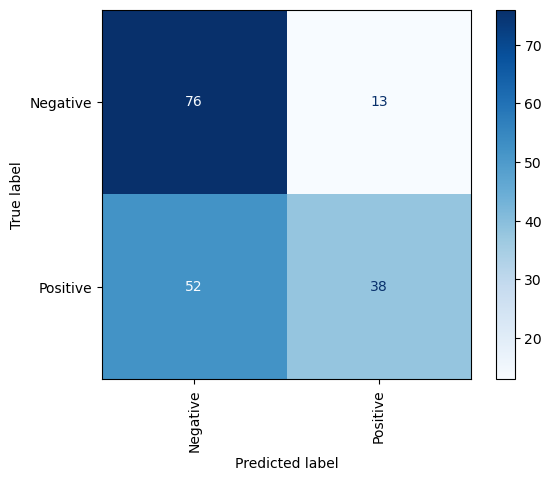

In [67]:
#validate model
%matplotlib inline
from sklearn.metrics import ConfusionMatrixDisplay as cmd
from sklearn.metrics import accuracy_score
cmd.from_estimator(model, x_test, y_test,
                   display_labels=['Negative', 'Positive'],
                   cmap='Blues', xticks_rotation='vertical')

# Get predictions
y_pred = model.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy: {accuracy:.2f}")

This has done a poor job of correctly identifying ositive sentiment. This could be because most of the data is relatievly neutral

In [69]:
#Showing mean values of posts to explain why model is so confused...
#a lot of "positive" sentiment values are quiet close to neutral
forum_posts['sentiment'].describe()

count    594.000000
mean       0.083612
std        0.236628
min       -0.800000
25%        0.000000
50%        0.015774
75%        0.200000
max        0.850000
Name: sentiment, dtype: float64

In [71]:
#Testing model
review = "I was very dissapointed with winter wheat this year. It did very badly, there was very little yield"
model.predict_proba(vectorizer.transform([review]))

array([[0.53847969, 0.46152031]])

The model has not correctly identified that this review had a higher probability of being negative

In [74]:
#Testing model with positive review
review = "I was very happy with dawsum crop this year. My favourite form of winter wheat, i am delighted!"
model.predict_proba(vectorizer.transform([review]))

array([[0.63865446, 0.36134554]])

The model was sucessful in determining this positive review

## Including "neutral" option to improve model

In [78]:
# 0= negative, 1= neutral, 2= positive
forum_posts['Sentiment_neutral'] = forum_posts['sentiment'].apply(lambda x: 2 if x > 0.05 else (0 if x < -0.05 else 1))

In [80]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range = (1, 2), stop_words = 'english', min_df = 20)
x = vectorizer.fit_transform(forum_posts['Lemmas'])
y = forum_posts['Sentiment_neutral']

In [82]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0) 

In [84]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000, random_state = 0)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=0)

Accuracy: 0.49


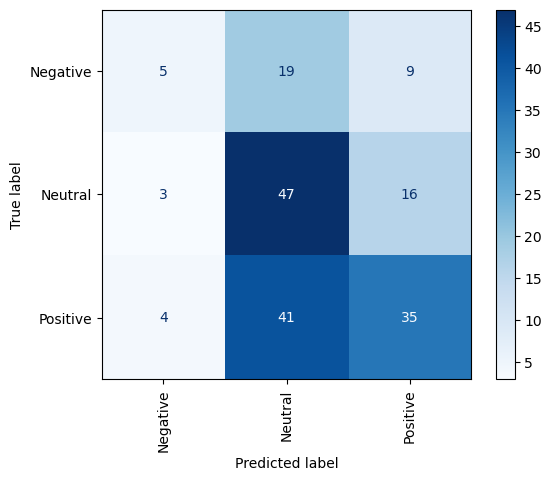

In [86]:
#validate model
%matplotlib inline
from sklearn.metrics import ConfusionMatrixDisplay as cmd

cmd.from_estimator(model, x_test, y_test,
                   display_labels=['Negative', 'Neutral', 'Positive'],
                   cmap='Blues', xticks_rotation='vertical')

# Get predictions
y_pred = model.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy: {accuracy:.2f}")

In [88]:
#Testing model
review = "I was very dissapointed with winter wheat this year. It did very badly, there was very little yield"
model.predict_proba(vectorizer.transform([review]))

array([[0.06687236, 0.41318875, 0.51993889]])

In [90]:
#Testing model with positive review
review = "I was very happy with dawsum crop this year. My favourite form of winter wheat, i am delighted!"
model.predict_proba(vectorizer.transform([review]))

array([[0.16125512, 0.5560544 , 0.28269048]])

In [92]:
#Testing model with positive review
review = "My crop yeild was fine. No issues."
model.predict_proba(vectorizer.transform([review]))

array([[0.20449866, 0.54526303, 0.2502383 ]])

Model is still quite poor - most coming as neutral.... chnage in neutral value has not helped that much - majority coming out as neutral

## VADER
- improve netrality rank etc with VADER

In [110]:
import warnings
warnings.filterwarnings('ignore') # We can suppress the warnings
#!pip install vaderSentiment


In [112]:
# Load thelibraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create and initialise an object
sent_analyzer = SentimentIntensityAnalyzer()

def format_data(forum_posts):

    # Change 0, 2, 4 to negative, neutral and positive
    labels = {0: 'negative', 1: 'neutral', 2: 'positive'}
    forum_posts['polarity'] = forum_posts['Sentiment_neutral'].map(labels)

    # Get only the two columns
    return forum_posts[['Lemmas', 'polarity']]

In [114]:
data=format_data(forum_posts)
data.head()

,Lemmas,polarity
0,issue sowing oat good broadleaf break know has...,positive
1,issue good break,positive
2,find good hungrier slower develop like put slu...,positive
3,alleopathy effect oat slow initially get nearl...,positive
4,wouldnt disagree partly fert tends put earlier...,neutral


In [116]:
#mapping compound scores to positive (≥0.05), negative (≤-0.05), and neutral classes. 
def format_output(output_dict):
  
  polarity = "neutral"

  if(output_dict['compound'] >= 0.05):
    polarity = "positive"

  elif(output_dict['compound'] <= -0.05):
    polarity = "negative"

  return polarity

def predict_sentiment(text):
  
  output_dict =  sent_analyzer.polarity_scores(text)
  return format_output(output_dict)

In [118]:
data["vader_prediction"] = data["Lemmas"].apply(predict_sentiment)

In [120]:
data.sample(5)

,Lemmas,polarity,vader_prediction
72,yeah packer stay plough even turning headland,neutral,positive
261,done little sunshine,negative,positive
40,type machine sowing stone werent issue id say ...,positive,positive
488,kph,neutral,neutral
519,hand sample champion afternoon 223 could defin...,neutral,positive


In [122]:
#confusion matrix

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(data['polarity'], data['vader_prediction'])

print("Accuracy: {}\n".format(accuracy))

# Show the classification report
print(classification_report(data['polarity'], data['vader_prediction']))

Accuracy: 0.6060606060606061

              precision    recall  f1-score   support

    negative       0.41      0.52      0.46       108
     neutral       0.64      0.48      0.55       213
    positive       0.68      0.74      0.71       273

    accuracy                           0.61       594
   macro avg       0.58      0.58      0.57       594
weighted avg       0.62      0.61      0.61       594



moderately good - not much better than a random guess, but better noetheless!

In [124]:
# Pre-Prcoessing and Bag of Word Vectorization using Count Vectorizer
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

token = RegexpTokenizer(r'[a-zA-Z0-9]+')
cv    = CountVectorizer(stop_words = 'english',ngram_range = (1, 1),tokenizer = token.tokenize)
text_counts = cv.fit_transform(data['Lemmas'])

text_counts

<594x2522 sparse matrix of type '<class 'numpy.int64'>'
	with 7787 stored elements in Compressed Sparse Row format>

In [126]:
#Splitting the data into trainig and testing
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(text_counts, data['polarity'], test_size=0.25, random_state=5)

In [128]:
text_counts.shape, X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((594, 2522), (445, 2522), (149, 2522), (445,), (149,))

In [130]:
# Training the model
from sklearn.naive_bayes import MultinomialNB
MNB = MultinomialNB()
MNB.fit(X_train, Y_train)

# Caluclating the accuracy score of the model
from sklearn import metrics
predicted = MNB.predict(X_test)
accuracy_score = metrics.accuracy_score(predicted, Y_test)
print("Accuracy Score: ",accuracy_score)

Accuracy Score:  0.4966442953020134


poor model

## Machine Learning
Discovering underlying topics
https://www.datacamp.com/tutorial/what-is-topic-modeling

In [134]:
#!pip install --upgrade scipy
#!pip install --upgrade gensim

In [136]:
#installing genism library to create a term-document matrix 
from gensim import corpora

# Creating document-term matrix 
dictionary = corpora.Dictionary(forum_posts['Tokenized'])
doc_term_matrix = [dictionary.doc2bow(doc) for doc in forum_posts['Tokenized']]
doc_term_matrix[0]

[(0, 1),
 (1, 1),
 (2, 1),
 (3, 1),
 (4, 1),
 (5, 1),
 (6, 1),
 (7, 1),
 (8, 1),
 (9, 1)]

# Modeling
- LSA
- LDA

In [139]:
from gensim.models import LsiModel

# LSA model
lsa = LsiModel(doc_term_matrix, num_topics=7, id2word = dictionary)

# LSA model
print(lsa.print_topics(num_topics=7, num_words=7))

[(0, '-0.308*"septoria" + -0.284*"varieties" + -0.256*"years" + -0.196*"one" + -0.195*"breeders" + -0.167*"really" + -0.155*"resistance"'), (1, '-0.214*"good" + 0.194*"breeders" + 0.190*"septoria" + -0.174*"also" + 0.161*"varieties" + -0.138*"takeall" + -0.137*"id"'), (2, '-0.514*"takeall" + -0.292*"also" + -0.207*"years" + -0.177*"disease" + -0.175*"generally" + -0.126*"effects" + -0.125*"people"'), (3, '-0.360*"im" + -0.265*"moddus" + -0.190*"second" + -0.162*"isnt" + -0.156*"variety" + -0.148*"ccc" + -0.144*"pgr"'), (4, '0.355*"ive" + 0.242*"id" + -0.183*"one" + -0.173*"like" + 0.169*"plants" + 0.167*"slug" + 0.163*"years"'), (5, '0.478*"good" + -0.257*"2" + 0.199*"also" + -0.182*"years" + 0.172*"septoria" + -0.160*"one" + 0.130*"disease"'), (6, '-0.254*"spring" + -0.174*"oats" + -0.168*"one" + -0.151*"seed" + -0.148*"fields" + 0.142*"acres" + 0.139*"like"')]


In [140]:
# Materialize the sparse data
data_dense = post_vect.todense()

# Compute Sparsicity = Percentage of Non-Zero cells
print("Sparsicity: ", ((data_dense > 0).sum()/data_dense.size)*100, "%")

Sparsicity:  1.0151515151515151 %


GridSearchCV resources: https://towardsdatascience.com/gridsearchcv-for-beginners-db48a90114ee
using GridSearch with lda etc: https://www.machinelearningplus.com/nlp/topic-modeling-python-sklearn-examples/
Other : https://yanlinc.medium.com/how-to-build-a-lda-topic-model-using-from-text-601cdcbfd3a6
Hyperameter tuning: https://github.com/dany-kuznetsov/topic_model_lda_hyper_params_opt

In [144]:
from gensim.models import LdaModel

# LDA model
lda = LdaModel(doc_term_matrix, num_topics=7, id2word = dictionary)

# Results
print(lda.print_topics(num_topics=7, num_words=7))

[(0, '0.007*"early" + 0.007*"2" + 0.006*"good" + 0.005*"well" + 0.005*"sowing" + 0.005*"got" + 0.005*"back"'), (1, '0.008*"good" + 0.006*"enough" + 0.006*"well" + 0.005*"see" + 0.005*"dont" + 0.005*"like" + 0.004*"got"'), (2, '0.006*"next" + 0.005*"time" + 0.005*"put" + 0.005*"week" + 0.005*"better" + 0.005*"one" + 0.004*"spray"'), (3, '0.007*"septoria" + 0.007*"years" + 0.006*"one" + 0.006*"varieties" + 0.005*"well" + 0.005*"take" + 0.005*"need"'), (4, '0.007*"oats" + 0.007*"good" + 0.007*"like" + 0.007*"id" + 0.006*"go" + 0.005*"much" + 0.005*"days"'), (5, '0.007*"like" + 0.006*"one" + 0.006*"2" + 0.005*"ive" + 0.005*"varieties" + 0.005*"good" + 0.004*"years"'), (6, '0.007*"first" + 0.006*"seed" + 0.005*"champion" + 0.005*"take" + 0.005*"beans" + 0.005*"im" + 0.005*"got"')]


In [145]:
from sklearn.decomposition import LatentDirichletAllocation
corpus =forum_posts['Lemmas']

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus).toarray()

# Display the feature names in sorted order
print(vectorizer.get_feature_names_out())


['01l' '02' '035' ... 'zero' 'zetor' 'zon']


## Re apply first sentiment model after removing more frequent words that were originally kept for context
- have one column with these words removed and run same code to see if this improves the model. Can keep other column for "basket case" or similar models... woord cloud etc if choose to do these later.

In [147]:
#listing freq words that were not previously dropped
freq = ["wheat", "winter", "barley", "dawsum", "sown", "field", "crop"] 
forum_posts['No freq'] = forum_posts['Thread Content'].apply(lambda x: " ".join(x for x in 
x.split() if x not in freq)) 
forum_posts['No freq'].head() 

0    issues sowing oats good broadleaf break know h...
1                                    issues good break
2    find good hungrier slower develop like put slu...
3    alleopathy effect oats slow initially gets nea...
4    wouldnt disagree partly fert tends put earlier...
Name: No freq, dtype: object

In [151]:
#Tokenization
# Tokenize the 'Thread Content' column for all rows
forum_posts['Tokenized no freq'] = forum_posts['No freq'].apply(lambda x: TextBlob(str(x)).words)

# Display the result
forum_posts[['No freq','Tokenized no freq']].head()

,No freq,Tokenized no freq
0,issues sowing oats good broadleaf break know h...,"[issues, sowing, oats, good, broadleaf, break,..."
1,issues good break,"[issues, good, break]"
2,find good hungrier slower develop like put slu...,"[find, good, hungrier, slower, develop, like, ..."
3,alleopathy effect oats slow initially gets nea...,"[alleopathy, effect, oats, slow, initially, ge..."
4,wouldnt disagree partly fert tends put earlier...,"[wouldnt, disagree, partly, fert, tends, put, ..."


In [153]:
# applying lemmatization to each tokenized word
forum_posts['Lemmas no freq'] = forum_posts['Tokenized no freq'].apply(lambda x: [Word(word).lemmatize() for word in x]).apply(lambda x: " ".join(x))

# See result
forum_posts[['No freq','Lemmas no freq']].head()

,No freq,Lemmas no freq
0,issues sowing oats good broadleaf break know h...,issue sowing oat good broadleaf break know has...
1,issues good break,issue good break
2,find good hungrier slower develop like put slu...,find good hungrier slower develop like put slu...
3,alleopathy effect oats slow initially gets nea...,alleopathy effect oat slow initially get nearl...
4,wouldnt disagree partly fert tends put earlier...,wouldnt disagree partly fert tends put earlier...


In [155]:
post_vect_nofreq = tfidf.fit_transform(forum_posts['Lemmas no freq']) 

In [157]:
posts_bow_nofreq = bow.fit_transform(forum_posts['Lemmas no freq']) 

In [159]:
# Sentiment analysis
forum_posts['sentiment no freq'] = forum_posts['Lemmas no freq'].apply(lambda x: 
TextBlob(x).sentiment[0] ) 
forum_posts[['Lemmas no freq','sentiment no freq']].head() 

,Lemmas no freq,sentiment no freq
0,issue sowing oat good broadleaf break know has...,0.325000
1,issue good break,0.700000
2,find good hungrier slower develop like put slu...,0.135417
3,alleopathy effect oat slow initially get nearl...,0.100000
4,wouldnt disagree partly fert tends put earlier...,0.050000


In [161]:
forum_posts['Sentiment no freq'] = forum_posts['sentiment no freq'].apply(lambda x: 1 if x > 0 else 0)

In [163]:
vectorizer = CountVectorizer(ngram_range = (1, 2), stop_words = 'english', min_df = 20)
x = vectorizer.fit_transform(forum_posts['Lemmas no freq'])
y = forum_posts['Sentiment no freq']

In [165]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0) 

In [167]:
#Logistic regression
model = LogisticRegression(max_iter = 1000, random_state = 0)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=0)

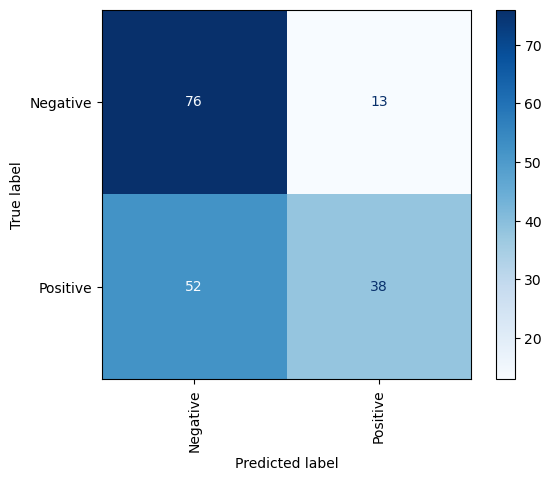

In [173]:
#validate model
%matplotlib inline
from sklearn.metrics import ConfusionMatrixDisplay as cmd

cmd.from_estimator(model, x_test, y_test,
                   display_labels=['Negative', 'Positive'],
                   cmap='Blues', xticks_rotation='vertical')

In [175]:
#Testing model
review = "I was very dissapointed with winter wheat this year. It did very badly, there was very little yield"
model.predict_proba(vectorizer.transform([review]))

array([[0.53847969, 0.46152031]])

In [177]:
#Testing model with positive review
review = "I was very happy with dawsum crop this year. My favourite form of winter wheat, I am delighted!"
model.predict_proba(vectorizer.transform([review]))

array([[0.63865446, 0.36134554]])

Model has performed exactly the same as before. Have checked code but cannot see any error that mayhave caused this to come back the same. Assuming then that removing the more frequent words has had no effect on the model. The main issue here is my small sample size